In [2]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [3]:
# Set the random seed for reproducibility
np.random.seed(42)

In [4]:
# Create sample dataset with outliers
df = pd.DataFrame({
    'height': np.concatenate([
        np.random.normal(175, 7, 95),  # Normal heights in cm
        np.array([150, 155, 200, 205, 210])  # Outliers
    ]),
    'weight': np.concatenate([
        np.random.normal(70, 10, 95),  # Normal weights in kg
        np.array([40, 45, 120, 125, 130])  # Outliers
    ]),
    'salary': np.concatenate([
        np.random.lognormal(10.5, 0.4, 95),  # Normal salaries
        np.array([500000, 520000, 550000, 600000, 1000000])  # Outliers
    ])
})

In [5]:
# Display dataset head and basic statistics
df.head()

,height,weight,salary
0,178.476999,55.364851,30375.572226
1,174.032150,72.961203,51152.135370
2,179.533820,72.610553,39562.520524
3,185.661209,70.051135,22064.041668
4,173.360926,67.654129,38920.343822


In [6]:
# Quick data summary
df.describe()


,height,weight,salary
count,100.000000,100.000000,100.000000
mean,174.802581,71.397280,70575.816571
std,8.824677,13.932214,138019.017873
min,150.000000,40.000000,9931.760814
25%,170.712081,61.943395,27742.715939
50%,174.111306,70.841072,38441.915870
75%,178.918874,76.333889,51091.331090
max,210.000000,130.000000,1000000.000000


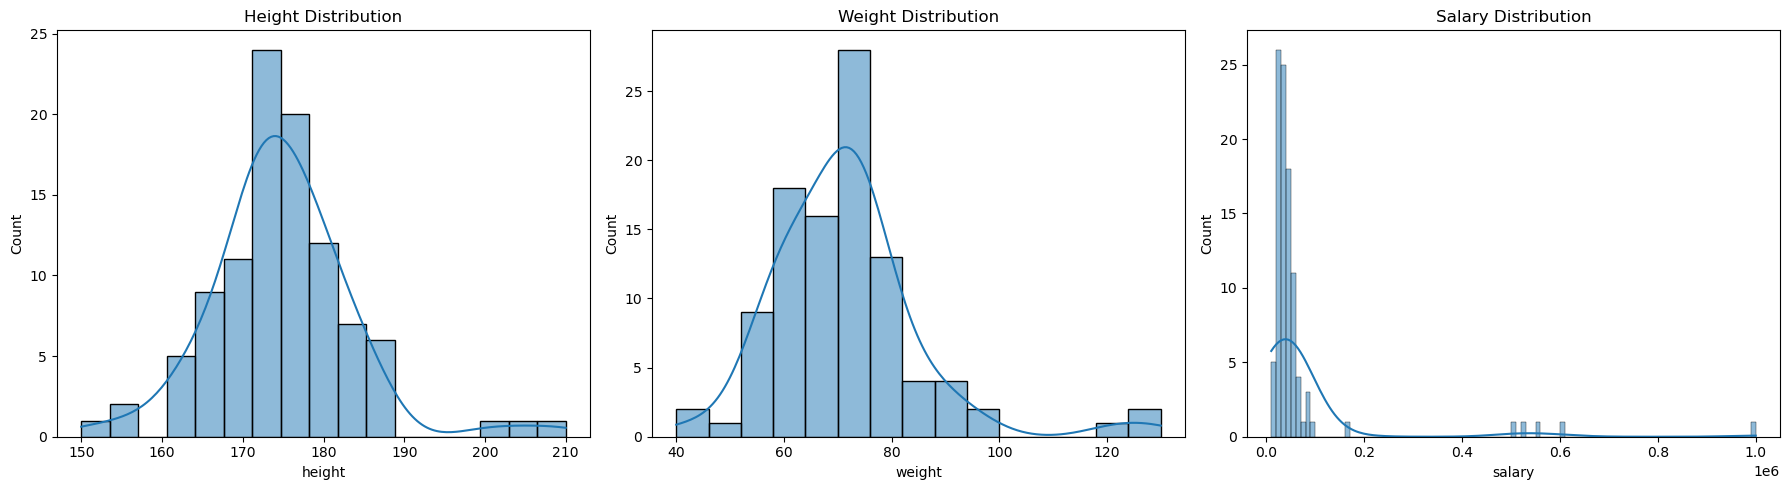

In [7]:
# Visualize distributions to identify potential outliers
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
sns.histplot(df['height'], kde=True)
plt.title('Height Distribution')

plt.subplot(1, 3, 2)
sns.histplot(df['weight'], kde=True)
plt.title('Weight Distribution')

plt.subplot(1, 3, 3)
sns.histplot(df['salary'], kde=True)
plt.title('Salary Distribution')

plt.tight_layout()
plt.show()

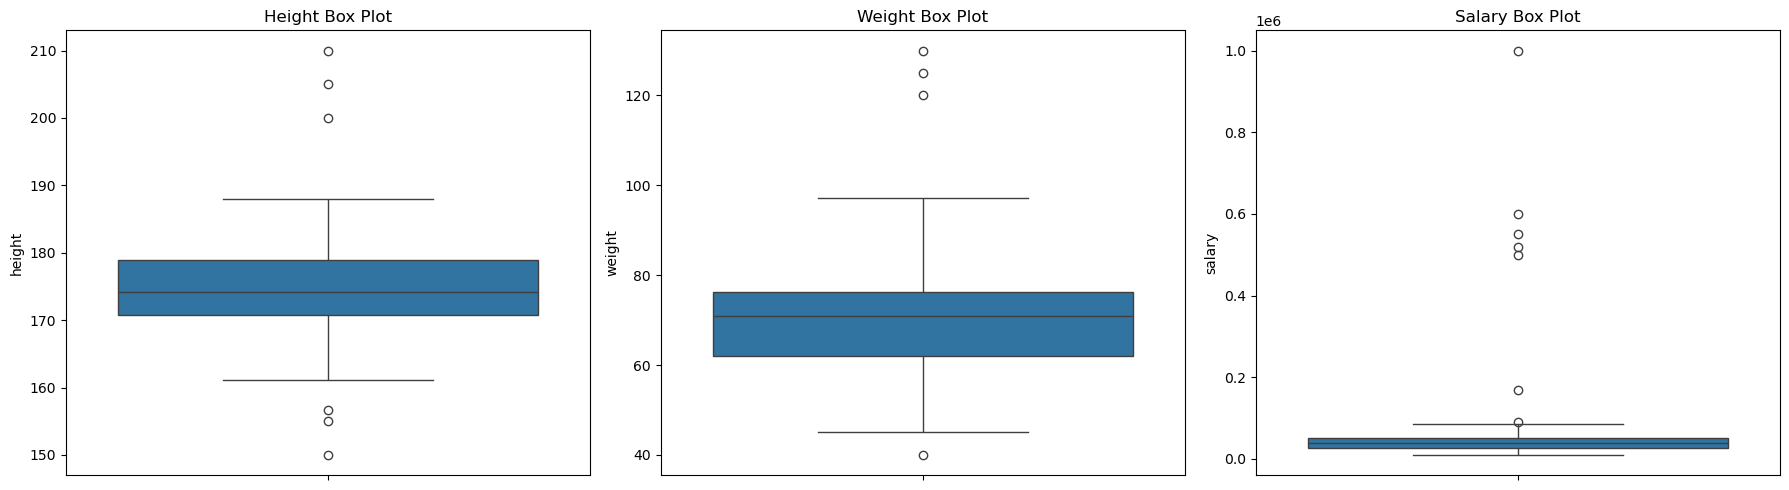

In [8]:
# Box plots to visualize potential outliers
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
sns.boxplot(y=df['height'])
plt.title('Height Box Plot')

plt.subplot(1, 3, 2)
sns.boxplot(y=df['weight'])
plt.title('Weight Box Plot')

plt.subplot(1, 3, 3)
sns.boxplot(y=df['salary'])
plt.title('Salary Box Plot')

plt.tight_layout()
plt.show()

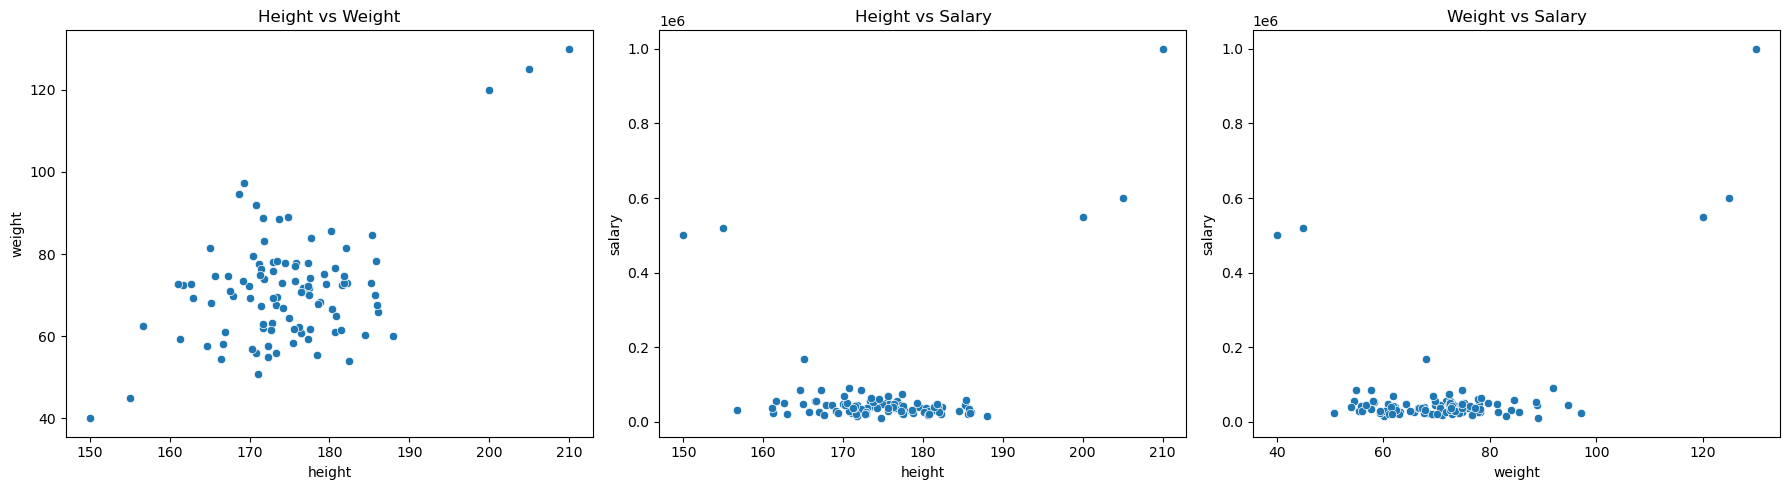

In [9]:
# Scatter plots to identify patterns and potential outliers
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
sns.scatterplot(x='height', y='weight', data=df)
plt.title('Height vs Weight')

plt.subplot(1, 3, 2)
sns.scatterplot(x='height', y='salary', data=df)
plt.title('Height vs Salary')

plt.subplot(1, 3, 3)
sns.scatterplot(x='weight', y='salary', data=df)
plt.title('Weight vs Salary')

plt.tight_layout()
plt.show()

In [10]:
# Define function for Z-score outlier detection
def detect_outliers_zscore(data, threshold=3):
    """
    Detect outliers using Z-score method
    Returns indices of outliers
    """
    z_scores = np.abs(stats.zscore(data))
    return np.where(z_scores > threshold)[0]


In [11]:
# Apply Z-score outlier detection
height_outliers_z = detect_outliers_zscore(df['height'])
weight_outliers_z = detect_outliers_zscore(df['weight'])
salary_outliers_z = detect_outliers_zscore(df['salary'])

print(f"Height outliers (Z-score): {len(height_outliers_z)} found at indices {height_outliers_z}")
print(f"Weight outliers (Z-score): {len(weight_outliers_z)} found at indices {weight_outliers_z}")
print(f"Salary outliers (Z-score): {len(salary_outliers_z)} found at indices {salary_outliers_z}")


Height outliers (Z-score): 2 found at indices [98 99]
Weight outliers (Z-score): 3 found at indices [97 98 99]
Salary outliers (Z-score): 5 found at indices [95 96 97 98 99]


In [12]:
# Define function for IQR outlier detection
def detect_outliers_iqr(data, factor=1.5):
    """
    Detect outliers using IQR method
    Returns indices of outliers
    """
    q1, q3 = np.percentile(data, [25, 75])
    iqr = q3 - q1
    lower_bound = q1 - (factor * iqr)
    upper_bound = q3 + (factor * iqr)
    return np.where((data < lower_bound) | (data > upper_bound))[0]


In [13]:
# Apply IQR outlier detection
height_outliers_iqr = detect_outliers_iqr(df['height'])
weight_outliers_iqr = detect_outliers_iqr(df['weight'])
salary_outliers_iqr = detect_outliers_iqr(df['salary'])

print(f"Height outliers (IQR): {len(height_outliers_iqr)} found at indices {height_outliers_iqr}")
print(f"Weight outliers (IQR): {len(weight_outliers_iqr)} found at indices {weight_outliers_iqr}")
print(f"Salary outliers (IQR): {len(salary_outliers_iqr)} found at indices {salary_outliers_iqr}")


Height outliers (IQR): 6 found at indices [74 95 96 97 98 99]
Weight outliers (IQR): 4 found at indices [95 97 98 99]
Salary outliers (IQR): 7 found at indices [19 30 95 96 97 98 99]


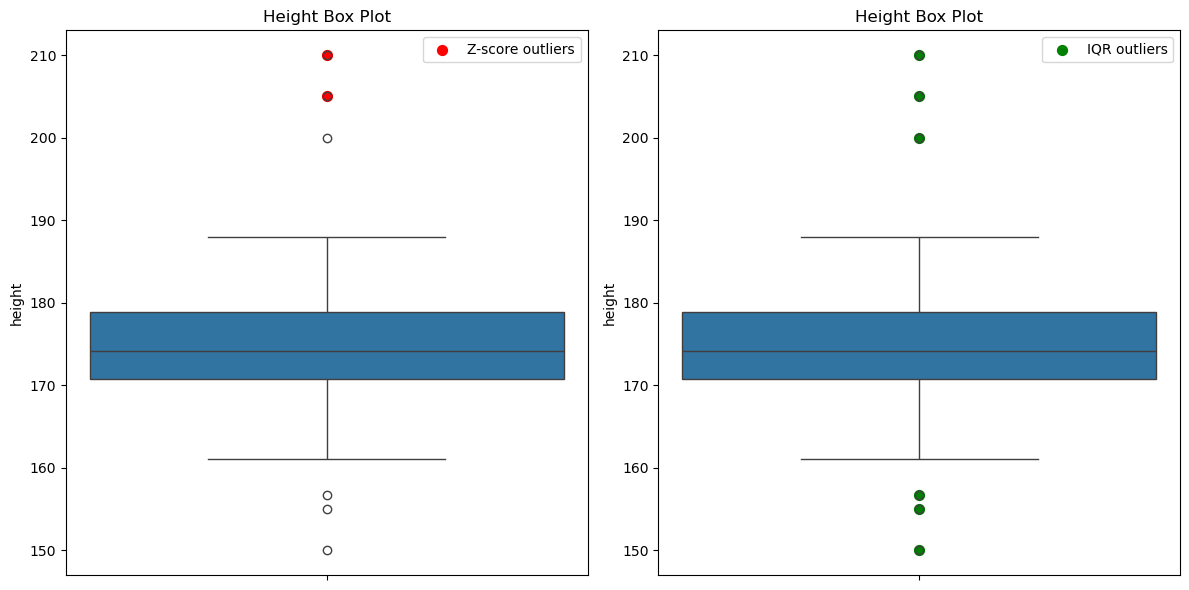

In [14]:
# Visualize the detected outliers for height using box plot with highlighted outliers
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.boxplot(y=df['height'])
plt.title('Height Box Plot')
plt.scatter(np.zeros_like(height_outliers_z), df['height'].iloc[height_outliers_z],
            color='red', s=50, label='Z-score outliers')
plt.legend()

plt.subplot(1, 2, 2)
sns.boxplot(y=df['height'])
plt.title('Height Box Plot')
plt.scatter(np.zeros_like(height_outliers_iqr), df['height'].iloc[height_outliers_iqr],
            color='green', s=50, label='IQR outliers')
plt.legend()

plt.tight_layout()
plt.show()


In [15]:
# Examining the impact of outliers on statistical measures
print("With outliers:")
print(f"Height mean: {df['height'].mean():.2f}, std: {df['height'].std():.2f}")
print(f"Weight mean: {df['weight'].mean():.2f}, std: {df['weight'].std():.2f}")
print(f"Salary mean: {df['salary'].mean():.2f}, std: {df['salary'].std():.2f}")


With outliers:
Height mean: 174.80, std: 8.82
Weight mean: 71.40, std: 13.93
Salary mean: 70575.82, std: 138019.02


In [16]:
# Create copies without outliers (using IQR method)
df_no_outliers = df.copy()
all_outliers = list(set(height_outliers_iqr) | set(weight_outliers_iqr) | set(salary_outliers_iqr))
df_no_outliers = df_no_outliers.drop(all_outliers).reset_index(drop=True)

print("\nWithout outliers:")
print(f"Height mean: {df_no_outliers['height'].mean():.2f}, std: {df_no_outliers['height'].std():.2f}")
print(f"Weight mean: {df_no_outliers['weight'].mean():.2f}, std: {df_no_outliers['weight'].std():.2f}")
print(f"Salary mean: {df_no_outliers['salary'].mean():.2f}, std: {df_no_outliers['salary'].std():.2f}")



Without outliers:
Height mean: 174.65, std: 6.18
Weight mean: 70.19, std: 9.50
Salary mean: 39059.91, std: 15713.95


In [17]:
# Handling outliers using different approaches
# 1. Removal (already done above)
# 2. Capping (Winsorization)
def winsorize(data, limits=(0.05, 0.05)):
    """Apply winsorization to limit extreme values"""
    lower_limit = np.percentile(data, limits[0] * 100)
    upper_limit = np.percentile(data, 100 - limits[1] * 100)
    return np.clip(data, lower_limit, upper_limit)

df_winsorized = df.copy()
df_winsorized['height'] = winsorize(df['height'])
df_winsorized['weight'] = winsorize(df['weight'])
df_winsorized['salary'] = winsorize(df['salary'])


In [18]:
# 3. Log transformation (especially useful for skewed data like salary)
df_log = df.copy()
df_log['salary'] = np.log(df['salary'])


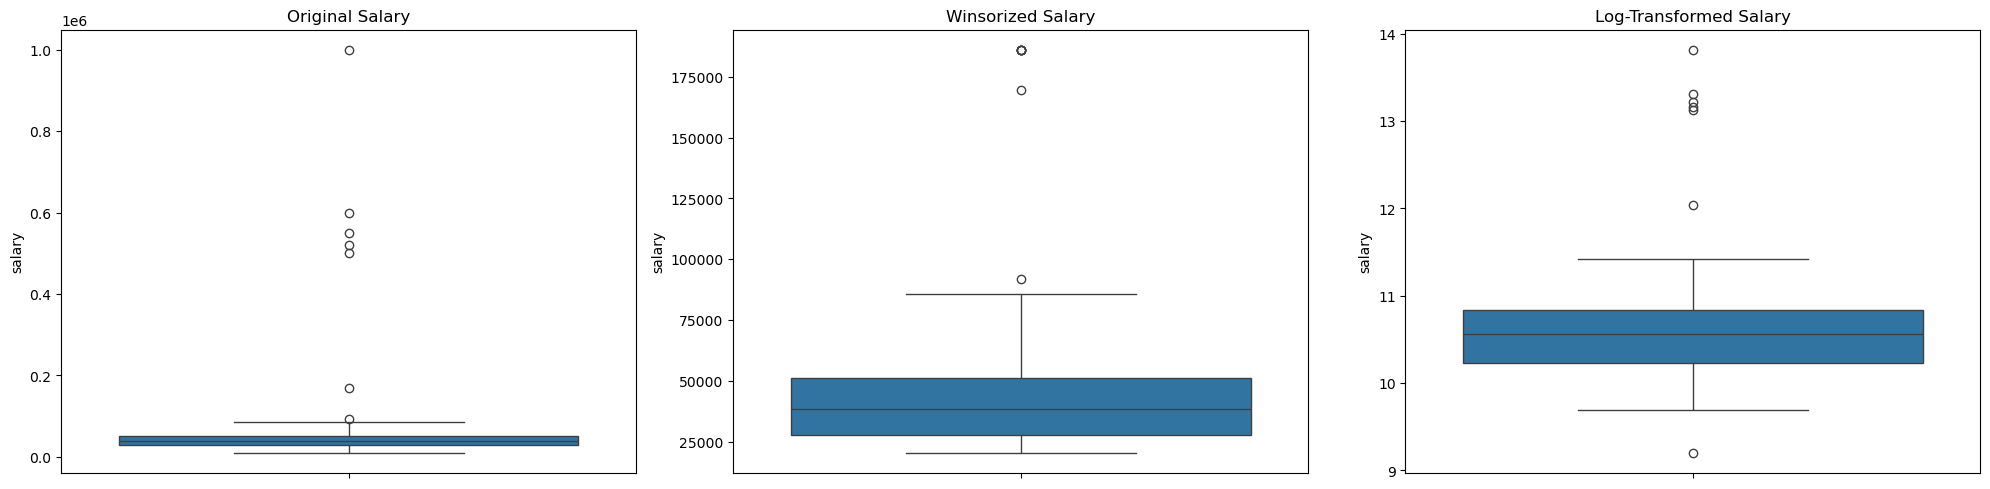

In [19]:
# Compare the distributions before and after transformation
plt.figure(figsize=(20, 5))

# Original distributions
plt.subplot(1, 3, 1)
sns.boxplot(y=df['salary'])
plt.title('Original Salary')

# After winsorization
plt.subplot(1, 3, 2)
sns.boxplot(y=df_winsorized['salary'])
plt.title('Winsorized Salary')

# After log transformation
plt.subplot(1, 3, 3)
sns.boxplot(y=df_log['salary'])
plt.title('Log-Transformed Salary')

plt.tight_layout()
plt.show()

In [20]:
# Feature associations and correlation analysis
# Calculate correlation matrix
corr_matrix = df.corr()


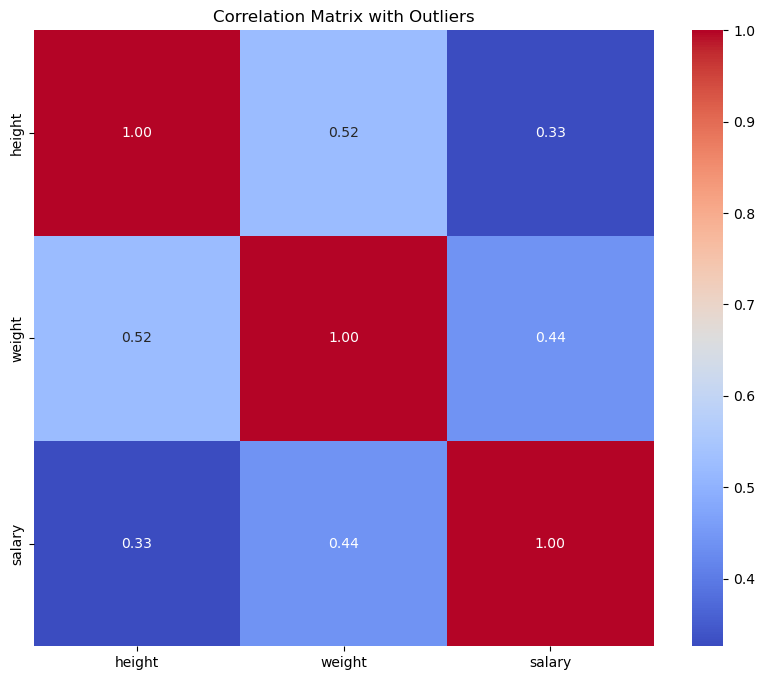

In [21]:
# Visualize the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix with Outliers')
plt.show()


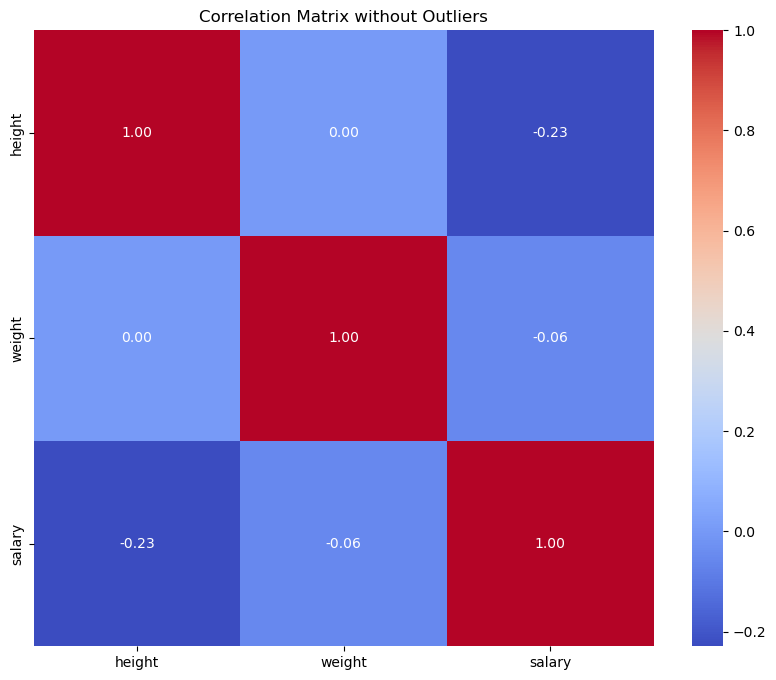

In [22]:
# Compare with correlation after removing outliers
corr_matrix_no_outliers = df_no_outliers.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix_no_outliers, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix without Outliers')
plt.show()


In [23]:
# Create function to profile features and detect potential issues
def profile_feature(data, feature_name):
    """Create a basic profile of a numeric feature"""
    feature = data[feature_name]

    # Basic statistics
    stats_dict = {
        'Count': len(feature),
        'Mean': feature.mean(),
        'Median': feature.median(),
        'Std Dev': feature.std(),
        'Min': feature.min(),
        'Max': feature.max(),
        'Range': feature.max() - feature.min(),
        'IQR': np.percentile(feature, 75) - np.percentile(feature, 25),
        'Skewness': stats.skew(feature),
        'Kurtosis': stats.kurtosis(feature),
        'Missing Values': feature.isna().sum(),
        'Missing %': feature.isna().mean() * 100
    }

    # Z-score outliers
    z_outliers = detect_outliers_zscore(feature)
    stats_dict['Z-score Outliers'] = len(z_outliers)
    stats_dict['Z-score Outlier %'] = len(z_outliers) / len(feature) * 100

    # IQR outliers
    iqr_outliers = detect_outliers_iqr(feature)
    stats_dict['IQR Outliers'] = len(iqr_outliers)
    stats_dict['IQR Outlier %'] = len(iqr_outliers) / len(feature) * 100

    return pd.Series(stats_dict, name=feature_name)


In [24]:
# Apply feature profiling to the dataset
profile_results = pd.DataFrame([
    profile_feature(df, 'height'),
    profile_feature(df, 'weight'),
    profile_feature(df, 'salary')
])

# Display the feature profiles
profile_results


,Count,Mean,Median,Std Dev,Min,Max,Range,IQR,Skewness,Kurtosis,Missing Values,Missing %,Z-score Outliers,Z-score Outlier %,IQR Outliers,IQR Outlier %
height,100.0,174.802581,174.111306,8.824677,150.000000,210.0,60.000000,8.206793,0.802248,3.330725,0.0,0.0,2.0,2.0,6.0,6.0
weight,100.0,71.397280,70.841072,13.932214,40.000000,130.0,90.000000,14.390494,1.587588,4.962706,0.0,0.0,3.0,3.0,4.0,4.0
salary,100.0,70575.816571,38441.915870,138019.017873,9931.760814,1000000.0,990068.239186,23348.615150,4.740303,23.787349,0.0,0.0,5.0,5.0,7.0,7.0


In [25]:
# Fixed function for multivariate outlier detection
def detect_multivariate_outliers(data, method='mahalanobis', threshold=0.99):
    """
    Detect multivariate outliers using Mahalanobis distance
    Returns indices of outliers
    """
    if method == 'mahalanobis':
        # Calculate Mahalanobis distance
        x = data.values
        covariance_matrix = np.cov(x, rowvar=False)
        inv_covariance_matrix = np.linalg.inv(covariance_matrix)
        mean_vector = np.mean(x, axis=0)

        # Implement mahalanobis distance manually
        mahalanobis_dist = []
        for i in range(x.shape[0]):
            x_i = x[i, :]
            # Calculate mahalanobis distance: (x-μ)ᵀΣ⁻¹(x-μ)
            diff = x_i - mean_vector
            mahal = np.sqrt(diff.dot(inv_covariance_matrix).dot(diff.T))
            mahalanobis_dist.append(mahal)

        # Convert to array
        mahalanobis_dist = np.array(mahalanobis_dist)

        # Find threshold using chi-squared distribution
        threshold_value = stats.chi2.ppf(threshold, df=x.shape[1])

        # Return indices of outliers
        return np.where(mahalanobis_dist > threshold_value)[0]
    else:
        raise ValueError("Only 'mahalanobis' method is currently supported")


In [26]:
# Apply multivariate outlier detection
multivariate_outliers = detect_multivariate_outliers(df, threshold=0.95)
print(f"Multivariate outliers: {len(multivariate_outliers)} found at indices {multivariate_outliers}")


Multivariate outliers: 0 found at indices []


<Figure size 1200x1000 with 0 Axes>

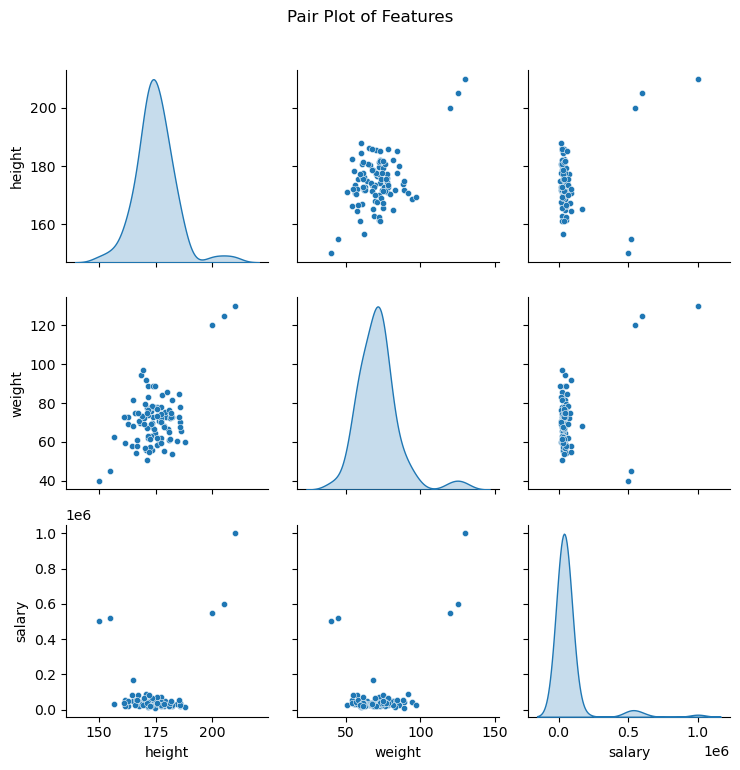

In [27]:
# Visualize the multivariate outliers in a pair plot
plt.figure(figsize=(12, 10))
sns.pairplot(df, diag_kind='kde', plot_kws={"s": 20})
plt.suptitle('Pair Plot of Features', y=1.02)
plt.tight_layout()
plt.show()

C:\Users\Fine Traders\AppData\Local\Temp\ipykernel_1536\3117540217.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


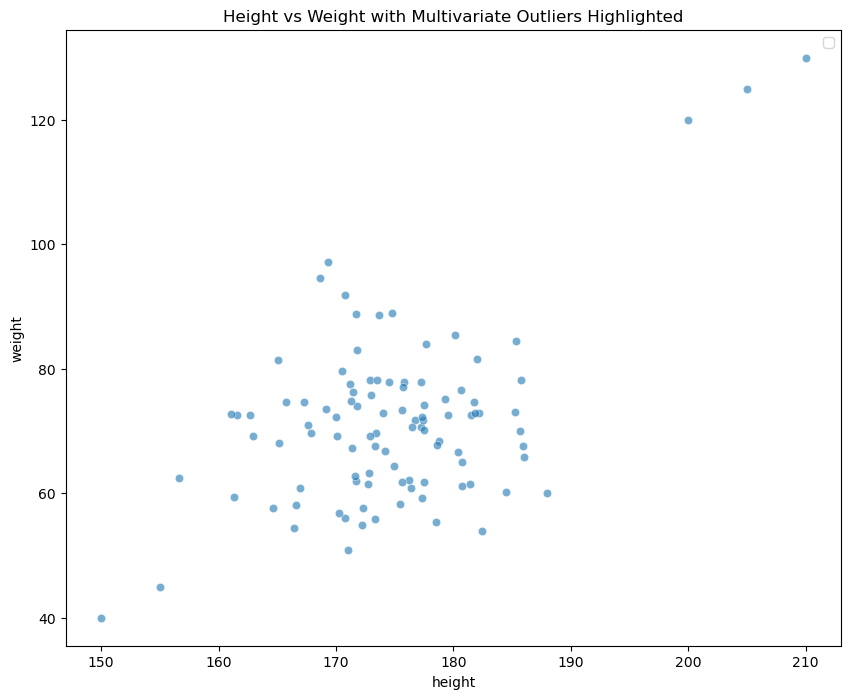

In [28]:
# Highlight the multivariate outliers in a scatter plot
plt.figure(figsize=(10, 8))
sns.scatterplot(x='height', y='weight', data=df, alpha=0.6)
sns.scatterplot(x='height', y='weight', data=df.iloc[multivariate_outliers],
                color='red', s=100, label='Multivariate Outliers')
plt.title('Height vs Weight with Multivariate Outliers Highlighted')
plt.legend()
plt.show()


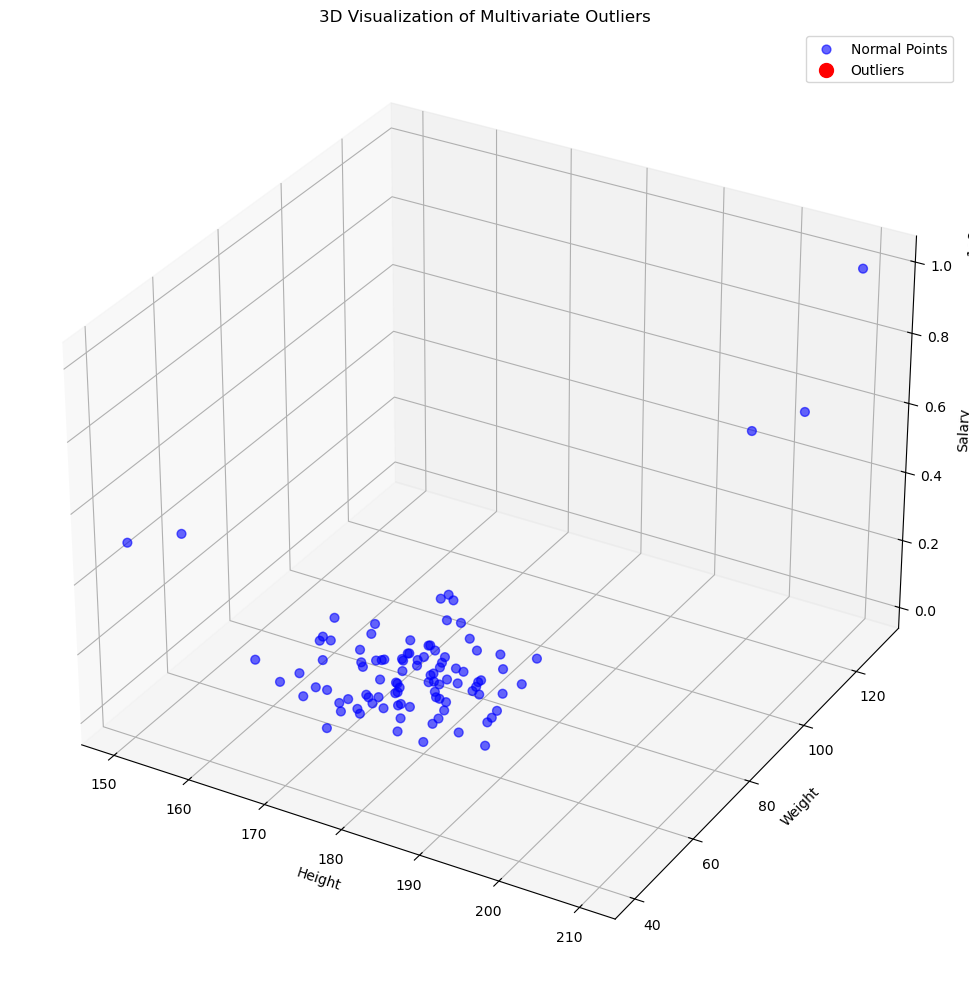

In [29]:
# 3D visualization of outliers
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Regular points
ax.scatter(df['height'], df['weight'], df['salary'], c='blue', s=40, alpha=0.6, label='Normal Points')
# Outliers
ax.scatter(df.iloc[multivariate_outliers]['height'], df.iloc[multivariate_outliers]['weight'],
           df.iloc[multivariate_outliers]['salary'], c='red', s=100, label='Outliers')

ax.set_xlabel('Height')
ax.set_ylabel('Weight')
ax.set_zlabel('Salary')
ax.set_title('3D Visualization of Multivariate Outliers')
plt.legend()
plt.tight_layout()
plt.show()


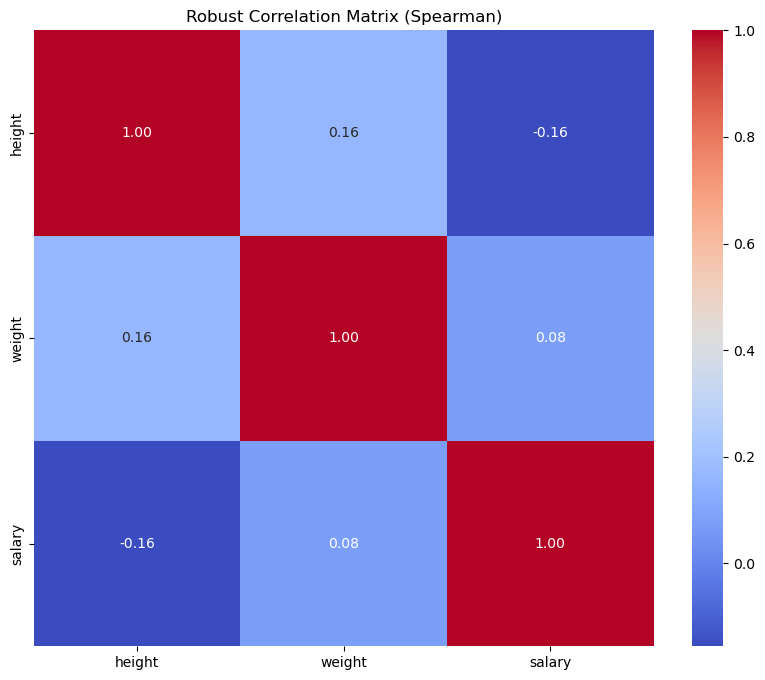

In [30]:
# Simple robust correlation calculation using Spearman instead of Pearson
robust_corr = df.corr(method='spearman')

plt.figure(figsize=(10, 8))
sns.heatmap(robust_corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Robust Correlation Matrix (Spearman)')
plt.show()


In [31]:
# Apply different scaling methods before and after outlier treatment
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler

In [32]:
# Original data
scaler_standard = StandardScaler()
df_scaled_standard = pd.DataFrame(
    scaler_standard.fit_transform(df),
    columns=df.columns
)


In [33]:
# Using robust scaler which is less influenced by outliers
scaler_robust = RobustScaler()
df_scaled_robust = pd.DataFrame(
    scaler_robust.fit_transform(df),
    columns=df.columns
)

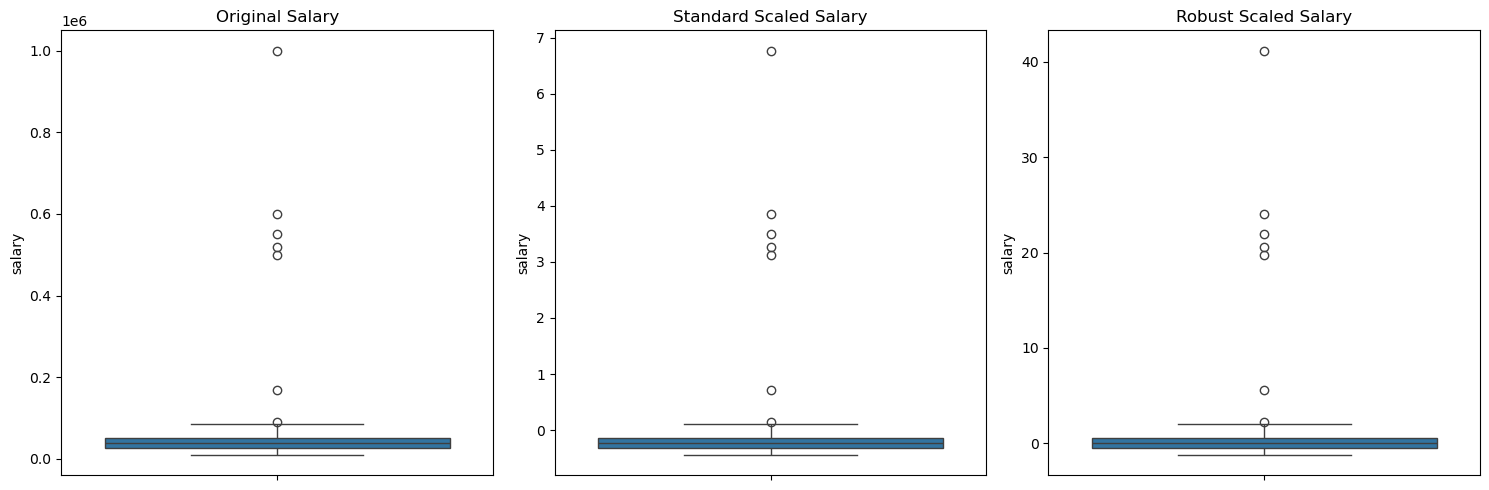

In [34]:
# Compare the scaled distributions
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.boxplot(y=df['salary'])
plt.title('Original Salary')

plt.subplot(1, 3, 2)
sns.boxplot(y=df_scaled_standard['salary'])
plt.title('Standard Scaled Salary')

plt.subplot(1, 3, 3)
sns.boxplot(y=df_scaled_robust['salary'])
plt.title('Robust Scaled Salary')

plt.tight_layout()
plt.show()


In [35]:
# Demonstrate impact of outliers on linear regression
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

In [36]:
# Create dataset with outlier
x = np.array(range(20)).reshape(-1, 1)
y = 2*x.ravel() + 5 + np.random.normal(0, 1, 20)
y[19] = 80  # add outlier

plt.figure(figsize=(12, 6))


<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

Text(0.5, 1.0, 'With Outlier: y = 2.57x + 1.40')

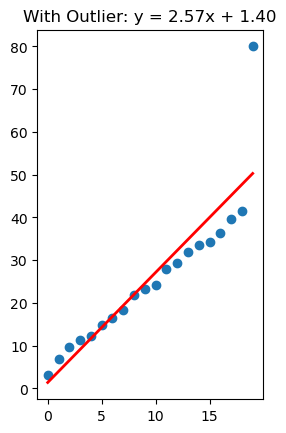

In [37]:
# Plot with outlier
plt.subplot(1, 2, 1)
plt.scatter(x, y)
model = LinearRegression().fit(x, y)
plt.plot(x, model.predict(x), color='red', linewidth=2)
plt.title(f'With Outlier: y = {model.coef_[0]:.2f}x + {model.intercept_:.2f}')


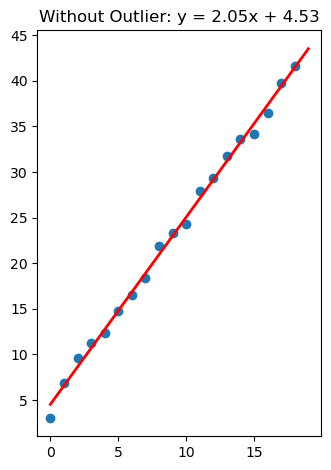

In [38]:
# Plot without outlier
plt.subplot(1, 2, 2)
plt.scatter(x[:-1], y[:-1])
model = LinearRegression().fit(x[:-1], y[:-1])
plt.plot(x, model.predict(x), color='red', linewidth=2)
plt.title(f'Without Outlier: y = {model.coef_[0]:.2f}x + {model.intercept_:.2f}')

plt.tight_layout()
plt.show()

In [39]:
# EXERCISE 1: Exploratory Data Analysis for Outlier Detection
# Create histograms and boxplots for at least 3 features

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.datasets import fetch_california_housing

# Load California Housing dataset
housing = fetch_california_housing()
X = pd.DataFrame(housing.data, columns=housing.feature_names)
y = housing.target
df = X.copy()
df['MedHouseVal'] = y

print("Dataset shape:", df.shape)
print("\nFeatures:", list(df.columns))
df.head()

Dataset shape: (20640, 9)

Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal']


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


Dataset loaded!
Shape: (20640, 9)



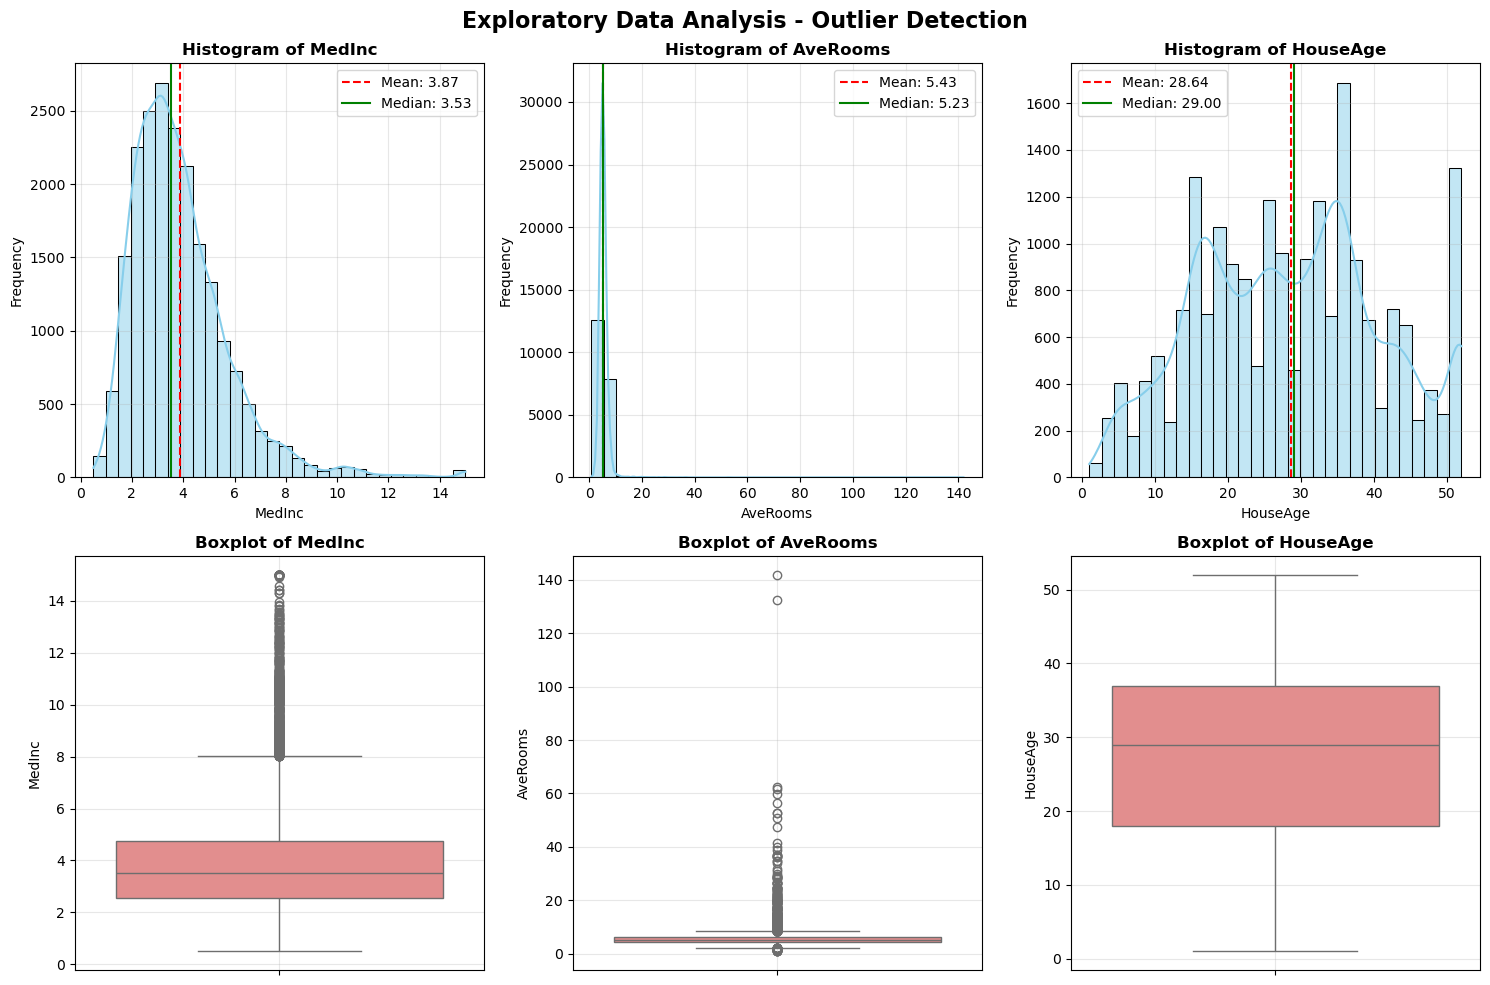

STATISTICAL SUMMARY

🔹 MedInc:
   Mean: 3.8707 | Median: 3.5348
   IQR: 2.1799 (Q1: 2.5634, Q3: 4.7432)
   Outlier bounds: [-0.7064, 8.0130]
   Outliers: 681 (3.30%)

🔹 AveRooms:
   Mean: 5.4290 | Median: 5.2291
   IQR: 1.6117 (Q1: 4.4407, Q3: 6.0524)
   Outlier bounds: [2.0232, 8.4699]
   Outliers: 511 (2.48%)

🔹 HouseAge:
   Mean: 28.6395 | Median: 29.0000
   IQR: 19.0000 (Q1: 18.0000, Q3: 37.0000)
   Outlier bounds: [-10.5000, 65.5000]
   Outliers: 0 (0.00%)


In [41]:
# EXERCISE 1: COMPLETE SOLUTION
# EDA for Outlier Detection

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.datasets import fetch_california_housing

# Load dataset
housing = fetch_california_housing()
X = pd.DataFrame(housing.data, columns=housing.feature_names)
y = housing.target
df = X.copy()
df['MedHouseVal'] = y

print("Dataset loaded!")
print(f"Shape: {df.shape}\n")

# Select features
features_to_plot = ['MedInc', 'AveRooms', 'HouseAge']

# CREATE FIGURES
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Exploratory Data Analysis - Outlier Detection', fontsize=16, fontweight='bold')

# HISTOGRAMS 
for i, feature in enumerate(features_to_plot):
    ax = axes[0, i]
    sns.histplot(df[feature], kde=True, bins=30, color='skyblue', ax=ax)
    
    # Add statistics
    mean_val = df[feature].mean()
    median_val = df[feature].median()
    ax.axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.2f}')
    ax.axvline(median_val, color='green', linestyle='-', label=f'Median: {median_val:.2f}')
    
    ax.set_title(f'Histogram of {feature}', fontweight='bold')
    ax.set_xlabel(feature)
    ax.set_ylabel('Frequency')
    ax.legend()
    ax.grid(True, alpha=0.3)

# BOXPLOTS 
for i, feature in enumerate(features_to_plot):
    ax = axes[1, i]
    sns.boxplot(y=df[feature], color='lightcoral', ax=ax)
    ax.set_title(f'Boxplot of {feature}', fontweight='bold')
    ax.set_ylabel(feature)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# STATISTICAL SUMMARY 
print("STATISTICAL SUMMARY")

for feature in features_to_plot:
    q1 = df[feature].quantile(0.25)
    q3 = df[feature].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = df[(df[feature] < lower) | (df[feature] > upper)]
    
    print(f"\n🔹 {feature}:")
    print(f"   Mean: {df[feature].mean():.4f} | Median: {df[feature].median():.4f}")
    print(f"   IQR: {iqr:.4f} (Q1: {q1:.4f}, Q3: {q3:.4f})")
    print(f"   Outlier bounds: [{lower:.4f}, {upper:.4f}]")
    print(f"   Outliers: {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)")

Data: [2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 100.0, 1.0, 4.2, 3.8]

Z-Score Outliers: []
IQR Outliers: [6, 7]

Common outliers: set()


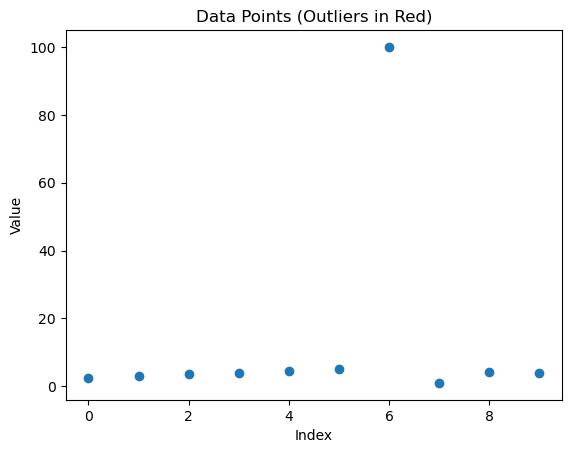

In [48]:
# EXERCISE 2 - SIMPLE SOLUTION

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# SAMPLE DATA
data = [2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 100.0, 1.0, 4.2, 3.8]
print("Data:", data)

# Z-SCORE METHOD
mean = np.mean(data)
std = np.std(data)

z_outliers = []
for i, val in enumerate(data):
    z = abs((val - mean) / std)
    if z > 3:
        z_outliers.append(i)

print("\nZ-Score Outliers:", z_outliers)

# IQR METHOD
q1 = np.percentile(data, 25)
q3 = np.percentile(data, 75)
iqr = q3 - q1

lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

iqr_outliers = []
for i, val in enumerate(data):
    if val < lower or val > upper:
        iqr_outliers.append(i)

print("IQR Outliers:", iqr_outliers)

# COMPARE
common = set(z_outliers) & set(iqr_outliers)
print("\nCommon outliers:", common)

# VISUALIZE
plt.scatter(range(len(data)), data)
plt.title("Data Points (Outliers in Red)")
plt.xlabel("Index")
plt.ylabel("Value")
plt.show()

First 10 values: [8.3252 8.3014 7.2574 5.6431 3.8462 4.0368 3.6591 3.12   2.0804 3.6912]
Mean: 2.177805
Std: 1.42273833183583

Z-Score outliers: 3
Indices: [0, 1, 2]

IQR outliers: 5
Indices: [0, 1, 2, 3, 61]


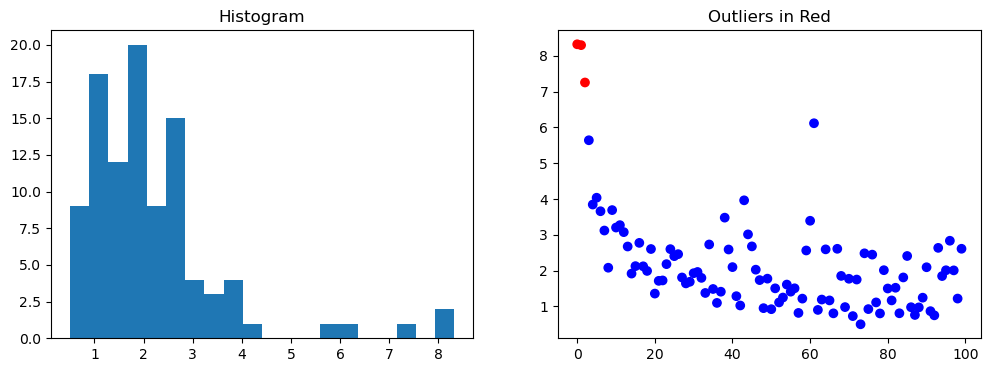

In [47]:
# REAL DATA - SIMPLE SOLUTION

from sklearn.datasets import fetch_california_housing

# Load data
housing = fetch_california_housing()
X = pd.DataFrame(housing.data, columns=housing.feature_names)

# Take MedInc column
data = X['MedInc'].values[:100]  # Sirf 100 values (fast)

print("First 10 values:", data[:10])
print("Mean:", np.mean(data))
print("Std:", np.std(data))

# Z-SCORE
mean = np.mean(data)
std = np.std(data)

z_outliers = []
for i, val in enumerate(data):
    z = abs((val - mean) / std)
    if z > 3:
        z_outliers.append(i)

print("\nZ-Score outliers:", len(z_outliers))
print("Indices:", z_outliers[:10])

# IQR
q1 = np.percentile(data, 25)
q3 = np.percentile(data, 75)
iqr = q3 - q1

lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

iqr_outliers = []
for i, val in enumerate(data):
    if val < lower or val > upper:
        iqr_outliers.append(i)

print("\nIQR outliers:", len(iqr_outliers))
print("Indices:", iqr_outliers[:10])

# VISUALIZE
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(data, bins=20)
plt.title("Histogram")

plt.subplot(1, 2, 2)
colors = ['red' if i in z_outliers else 'blue' for i in range(len(data))]
plt.scatter(range(len(data)), data, color=colors)
plt.title("Outliers in Red")

plt.show()

Data shape: (20640, 2)

Outliers found: 1032


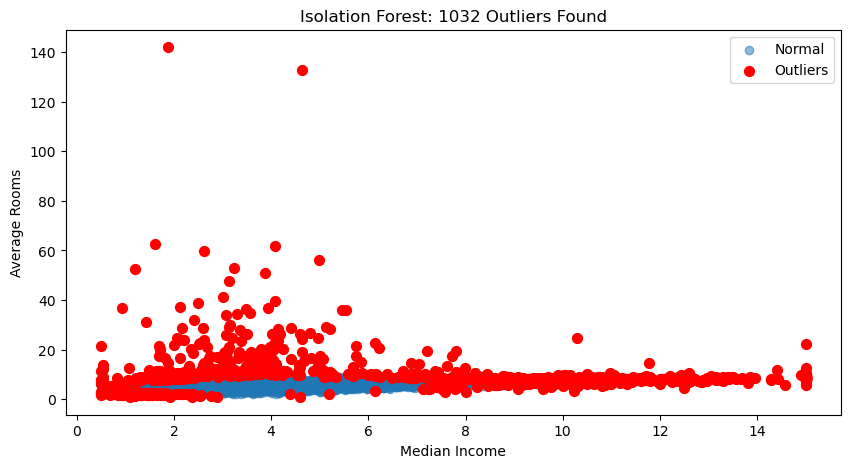

In [46]:
# EXERCISE 3 - ISOLATION FOREST (SIMPLE)

from sklearn.ensemble import IsolationForest
from sklearn.datasets import fetch_california_housing
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# LOAD DATA
housing = fetch_california_housing()
X = pd.DataFrame(housing.data, columns=housing.feature_names)

# Use 2 features
data = X[['MedInc', 'AveRooms']].values

print("Data shape:", data.shape)

# ISOLATION FOREST
model = IsolationForest(contamination=0.05, random_state=42)
predictions = model.fit_predict(data)

# -1 = outlier, 1 = normal
outlier_mask = predictions == -1
outlier_indices = np.where(outlier_mask)[0]

print(f"\nOutliers found: {len(outlier_indices)}")

# VISUALIZE
plt.figure(figsize=(10, 5))

# Normal points
normal = data[~outlier_mask]
plt.scatter(normal[:, 0], normal[:, 1], alpha=0.5, label='Normal')

# Outlier points
outliers = data[outlier_mask]
plt.scatter(outliers[:, 0], outliers[:, 1], 
           color='red', s=50, label='Outliers')

plt.xlabel('Median Income')
plt.ylabel('Average Rooms')
plt.title(f'Isolation Forest: {len(outlier_indices)} Outliers Found')
plt.legend()
plt.show()

COMPARISON RESULTS
All Data        : R² = 0.4734 | Coef = 0.4179
No Z-Score      : R² = 0.4321 | Coef = 0.4521
No IF           : R² = 0.3844 | Coef = 0.4531


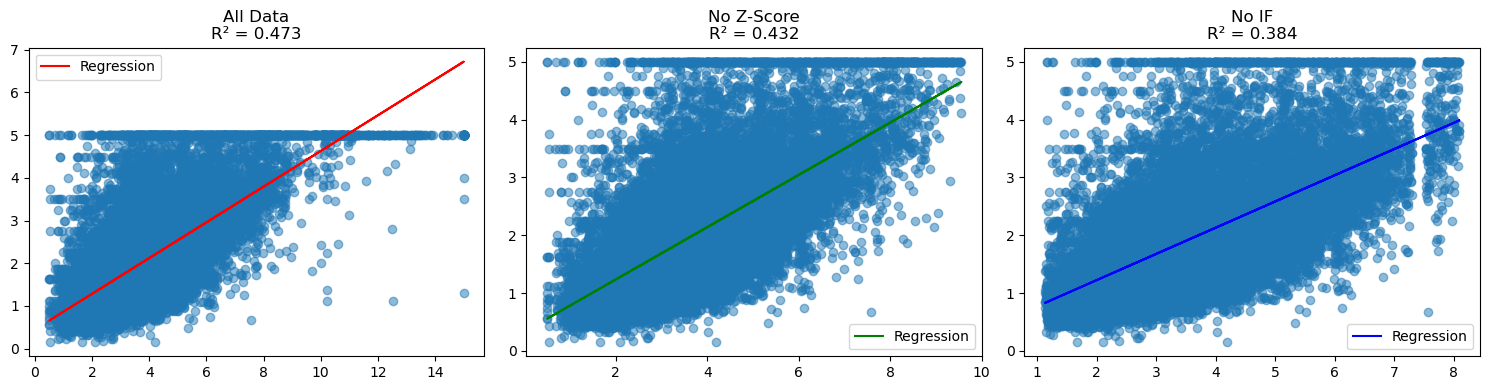


Best R² Score: 0.4734


In [45]:
# EXERCISE 4 - COMPLETE SIMPLE SOLUTION
# Impact of Outliers on Linear Regression

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.ensemble import IsolationForest

# LOAD DATA
housing = fetch_california_housing()
X = pd.DataFrame(housing.data, columns=housing.feature_names)
y = housing.target

# Use MedInc to predict MedHouseVal
X_feature = X[['MedInc']]
y_target = y

# FUNCTIONS 
def get_zscore_outliers(data, threshold=3):
    mean, std = np.mean(data), np.std(data)
    return [i for i, v in enumerate(data) if abs((v - mean) / std) > threshold]

def get_if_outliers(data, contamination=0.05):
    model = IsolationForest(contamination=contamination, random_state=42)
    return np.where(model.fit_predict(data) == -1)[0]

# MODEL 1: ALL DATA 
model_all = LinearRegression().fit(X_feature, y_target)
y_pred_all = model_all.predict(X_feature)
r2_all = r2_score(y_target, y_pred_all)

# MODEL 2: NO Z-SCORE 
z_out = get_zscore_outliers(X_feature.values.flatten())
X_no_z, y_no_z = np.delete(X_feature.values, z_out, 0), np.delete(y_target, z_out, 0)
model_no_z = LinearRegression().fit(X_no_z, y_no_z)
r2_no_z = r2_score(y_no_z, model_no_z.predict(X_no_z))

# MODEL 3: NO ISOLATION FOREST 
if_out = get_if_outliers(X_feature.values)
X_no_if, y_no_if = np.delete(X_feature.values, if_out, 0), np.delete(y_target, if_out, 0)
model_no_if = LinearRegression().fit(X_no_if, y_no_if)
r2_no_if = r2_score(y_no_if, model_no_if.predict(X_no_if))

# RESULTS 
print("COMPARISON RESULTS")
print(f"All Data        : R² = {r2_all:.4f} | Coef = {model_all.coef_[0]:.4f}")
print(f"No Z-Score      : R² = {r2_no_z:.4f} | Coef = {model_no_z.coef_[0]:.4f}")
print(f"No IF           : R² = {r2_no_if:.4f} | Coef = {model_no_if.coef_[0]:.4f}")

# VISUALIZE
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.scatter(X_feature, y_target, alpha=0.5)
plt.plot(X_feature, y_pred_all, 'r-', label='Regression')
plt.title(f'All Data\nR² = {r2_all:.3f}')
plt.legend()

plt.subplot(1, 3, 2)
plt.scatter(X_no_z, y_no_z, alpha=0.5)
plt.plot(X_no_z, model_no_z.predict(X_no_z), 'g-', label='Regression')
plt.title(f'No Z-Score\nR² = {r2_no_z:.3f}')
plt.legend()

plt.subplot(1, 3, 3)
plt.scatter(X_no_if, y_no_if, alpha=0.5)
plt.plot(X_no_if, model_no_if.predict(X_no_if), 'b-', label='Regression')
plt.title(f'No IF\nR² = {r2_no_if:.3f}')
plt.legend()

plt.tight_layout()
plt.show()

# SUMMARY
print(f"\nBest R² Score: {max(r2_all, r2_no_z, r2_no_if):.4f}")

Data loaded!

CUSTOM OUTLIER DETECTION: MedInc
Z-Score: 345 outliers
IQR: 681 outliers

Consensus: 345 outliers


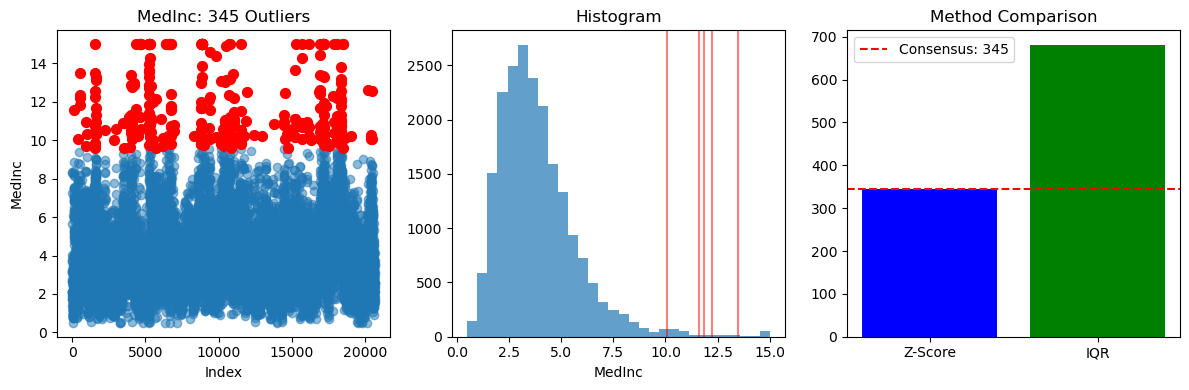


Consensus Outlier Values (first 10):
  Index 131: 11.6017
  Index 409: 10.0825
  Index 510: 11.8603
  Index 511: 13.4990
  Index 512: 12.2138
  Index 514: 12.3804
  Index 923: 9.7194
  Index 977: 10.9506
  Index 986: 10.3203
  Index 1541: 9.5862


In [49]:
# EXERCISE 5 - COMPLETE SIMPLE SOLUTION
# Custom Outlier Detection Workflow

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.datasets import fetch_california_housing
from sklearn.ensemble import IsolationForest

# LOAD DATA
housing = fetch_california_housing()
X = pd.DataFrame(housing.data, columns=housing.feature_names)
df = X.copy()

print("Data loaded!\n")

# DETECTION METHODS
def detect_zscore(data, threshold=3):
    mean, std = np.mean(data), np.std(data)
    return [i for i, v in enumerate(data) if abs((v - mean) / std) > threshold]

def detect_iqr(data, factor=1.5):
    q1, q3 = np.percentile(data, 25), np.percentile(data, 75)
    iqr = q3 - q1
    lower, upper = q1 - factor*iqr, q3 + factor*iqr
    return [i for i, v in enumerate(data) if v < lower or v > upper]

def detect_if(data, contamination=0.05):
    model = IsolationForest(contamination=contamination, random_state=42)
    return np.where(model.fit_predict(np.array(data).reshape(-1, 1)) == -1)[0]

# CUSTOM WORKFLOW 
def custom_outlier_detection(df, column, methods=['zscore', 'iqr']):
    data = df[column].values
    all_outliers = {}
    
    if 'zscore' in methods:
        all_outliers['Z-Score'] = detect_zscore(data)
    if 'iqr' in methods:
        all_outliers['IQR'] = detect_iqr(data)
    if 'if' in methods:
        all_outliers['IF'] = detect_if(data)
    
    # Consensus = intersection of all methods
    consensus = set(all_outliers[list(all_outliers.keys())[0]])
    for method, outliers in all_outliers.items():
        consensus = consensus & set(outliers)
    
    consensus = sorted(list(consensus))
    
    # Print results
    print(f"CUSTOM OUTLIER DETECTION: {column}")
    for method, outliers in all_outliers.items():
        print(f"{method}: {len(outliers)} outliers")
    print(f"\nConsensus: {len(consensus)} outliers")
    
    return consensus, all_outliers

# APPLY
feature = 'MedInc'
consensus, results = custom_outlier_detection(df, feature, methods=['zscore', 'iqr'])

# VISUALIZE
data = df[feature].values

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.scatter(range(len(data)), data, alpha=0.5)
plt.scatter(consensus, data[consensus], color='red', s=50)
plt.title(f'{feature}: {len(consensus)} Outliers')
plt.xlabel('Index')
plt.ylabel(feature)

plt.subplot(1, 3, 2)
plt.hist(data, bins=30, alpha=0.7)
if len(consensus) > 0:
    for idx in consensus[:5]:
        plt.axvline(data[idx], color='red', alpha=0.5)
plt.title('Histogram')
plt.xlabel(feature)

plt.subplot(1, 3, 3)
methods = list(results.keys())
counts = [len(results[m]) for m in methods]
plt.bar(methods, counts, color=['blue', 'green', 'orange'])
plt.axhline(y=len(consensus), color='red', linestyle='--', label=f'Consensus: {len(consensus)}')
plt.title('Method Comparison')
plt.legend()

plt.tight_layout()
plt.show()

# SHOW OUTLIERS
print("\nConsensus Outlier Values (first 10):")
for idx in consensus[:10]:
    print(f"  Index {idx}: {data[idx]:.4f}")

Data loaded!

OUTLIER COMPARISON
Original:  681 outliers
Log:       226 outliers
Sqrt:      397 outliers


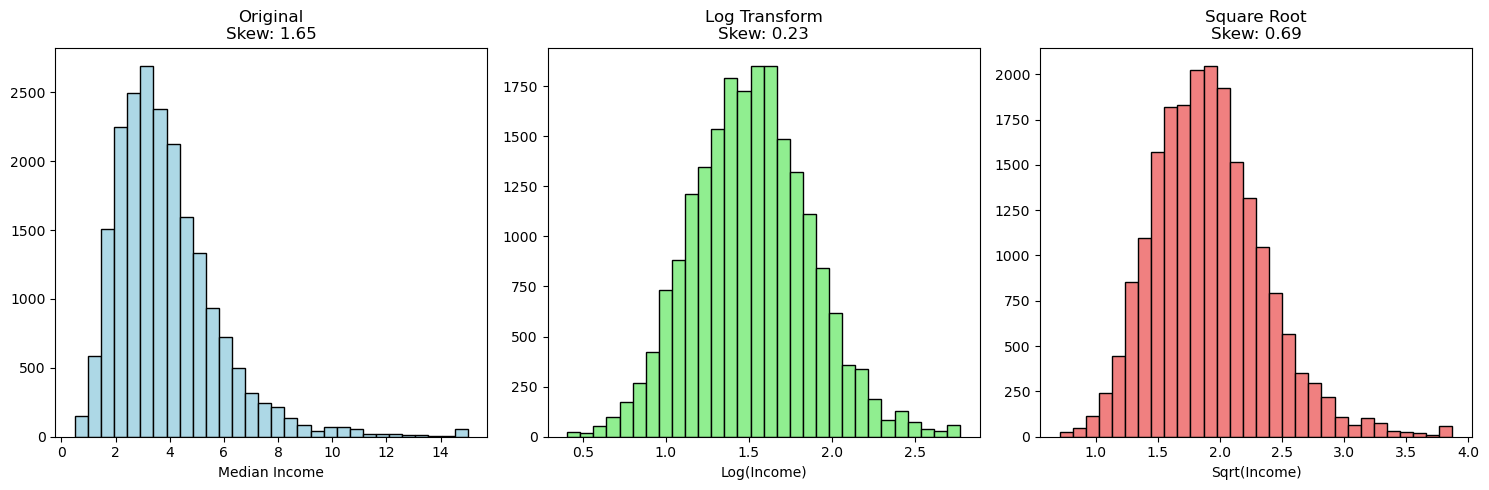

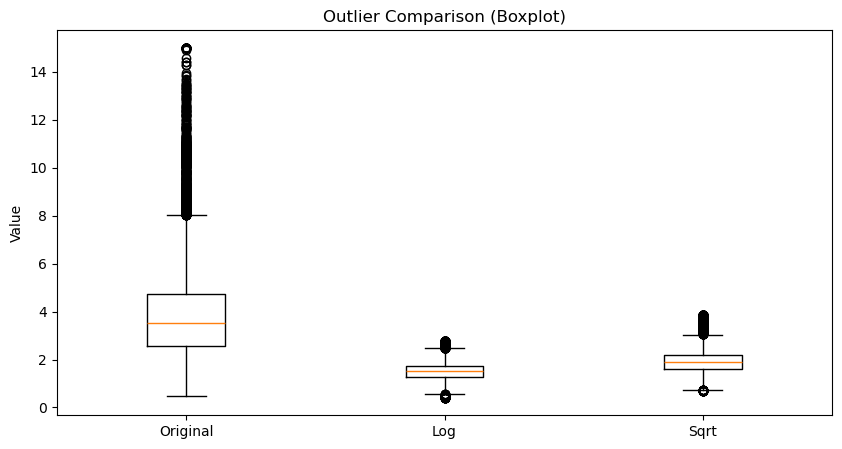


Log transformation best for reducing skewness and outliers!


In [52]:
# EXERCISE 6 - COMPLETE SIMPLE SOLUTION (FIXED)
# Robust Feature Engineering

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing

# LOAD DATA
housing = fetch_california_housing()
X = pd.DataFrame(housing.data, columns=housing.feature_names)
df = X.copy()
df['MedHouseVal'] = housing.target

print("Data loaded!\n")

# ORIGINAL
original = df['MedInc']

# TRANSFORMATIONS
df['Log'] = np.log(df['MedInc'] + 1)
df['Sqrt'] = np.sqrt(df['MedInc'])

# BINNING
bins = [0, 2, 4, 6, 8, 10, 15]
labels = ['Very Low', 'Low', 'Medium', 'High', 'Very High', 'Extreme']
df['Binned'] = pd.cut(df['MedInc'], bins=bins, labels=labels)

# RATIO 
df['Rooms_Per_Household'] = df['AveRooms'] / df['AveOccup']
df['Log_Rooms'] = np.log(df['Rooms_Per_Household'] + 1)

# CHECK OUTLIERS
def count_outliers(data):
    q1, q3 = data.quantile(0.25), data.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
    return len(data[(data < lower) | (data > upper)])

print("OUTLIER COMPARISON")
print(f"Original:  {count_outliers(original)} outliers")
print(f"Log:       {count_outliers(df['Log'])} outliers")
print(f"Sqrt:      {count_outliers(df['Sqrt'])} outliers")

# VISUALIZE
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.hist(original, bins=30, color='lightblue', edgecolor='black')
plt.title(f'Original\nSkew: {original.skew():.2f}')
plt.xlabel('Median Income')

plt.subplot(1, 3, 2)
plt.hist(df['Log'], bins=30, color='lightgreen', edgecolor='black')
plt.title(f'Log Transform\nSkew: {df["Log"].skew():.2f}')
plt.xlabel('Log(Income)')

plt.subplot(1, 3, 3)
plt.hist(df['Sqrt'], bins=30, color='lightcoral', edgecolor='black')
plt.title(f'Square Root\nSkew: {df["Sqrt"].skew():.2f}')
plt.xlabel('Sqrt(Income)')

plt.tight_layout()
plt.show()

# FIX: labels → tick_labels (Warning fix)
plt.figure(figsize=(10, 5))

# Yeh line change ki hai (labels → tick_labels)
plt.boxplot([original, df['Log'], df['Sqrt']], 
            tick_labels=['Original', 'Log', 'Sqrt'])  # ← FIXED!

plt.title('Outlier Comparison (Boxplot)')
plt.ylabel('Value')
plt.show()

print("\nLog transformation best for reducing skewness and outliers!")

Data loaded!
Shape: (20640, 3)
Features: ['MedInc', 'AveRooms', 'HouseAge']

RESULTS
Total points: 20640
Threshold: 7.8147
Outliers found: 49 (0.24%)
Indices: [1024 1102 1234 1238 1239 1240 1566 1867 1872 1912]...


<Figure size 1200x1000 with 0 Axes>

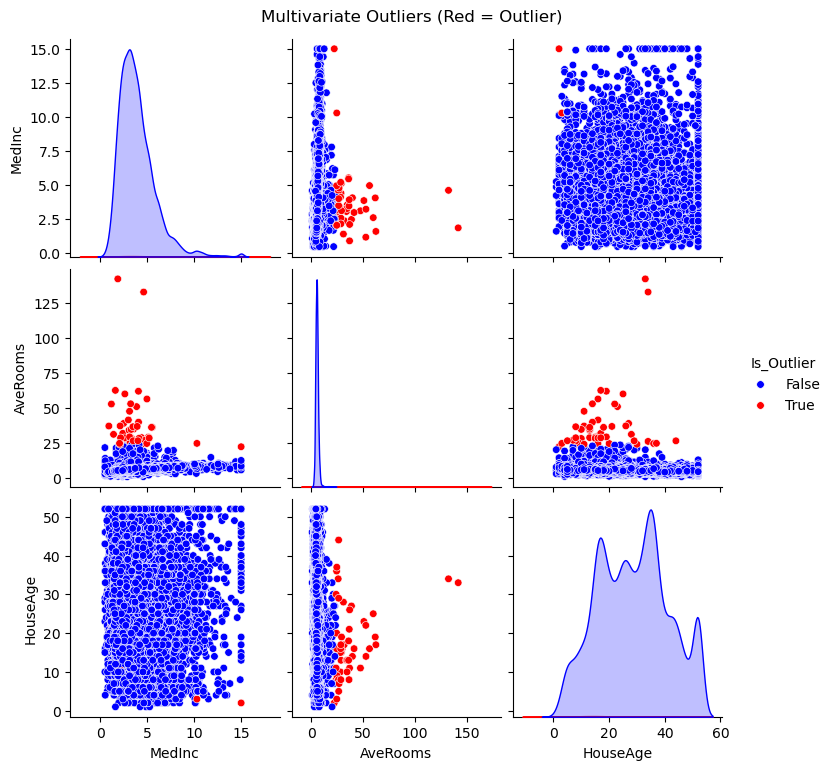

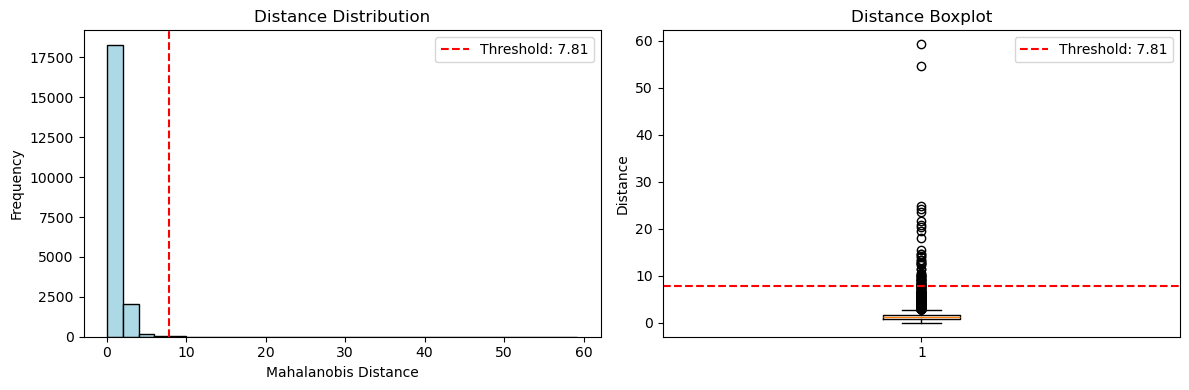


Outlier Values (first 5):
      MedInc   AveRooms  HouseAge   Distance
1024  3.1500  29.852941      16.0  10.586019
1102  2.4028  31.777778      17.0  11.568122
1234  4.4063  28.757282      13.0   9.883351
1238  3.3542  28.112903      10.0   9.804715
1239  3.0750  33.989691      13.0  12.368272


In [54]:
# EXERCISE 7 - FIXED (No Warnings)
# Multivariate Outlier Detection

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.datasets import fetch_california_housing

# LOAD DATA
housing = fetch_california_housing()
X = pd.DataFrame(housing.data, columns=housing.feature_names)
df = X.copy()
df['MedHouseVal'] = housing.target

# Select features
features = ['MedInc', 'AveRooms', 'HouseAge']

# FIX: .copy() use karo!
data = df[features].copy()

print("Data loaded!")
print(f"Shape: {data.shape}")
print(f"Features: {features}\n")

# MAHALANOBIS DISTANCE
def mahalanobis_distance(data):
    X = data.values
    mean = np.mean(X, axis=0)
    cov = np.cov(X, rowvar=False)
    inv_cov = np.linalg.inv(cov)
    
    distances = []
    for i in range(X.shape[0]):
        diff = X[i] - mean
        dist = np.sqrt(diff.dot(inv_cov).dot(diff.T))
        distances.append(dist)
    return np.array(distances)

# FIND OUTLIERS
distances = mahalanobis_distance(data)
threshold = stats.chi2.ppf(0.95, df=data.shape[1])
outliers = np.where(distances > threshold)[0]

print("RESULTS")
print(f"Total points: {len(data)}")
print(f"Threshold: {threshold:.4f}")
print(f"Outliers found: {len(outliers)} ({len(outliers)/len(data)*100:.2f}%)")
print(f"Indices: {outliers[:10]}...")

# VISUALIZE 
# FIX: .copy() use karo
data_plot = data.copy()
data_plot['Is_Outlier'] = False
data_plot.loc[outliers, 'Is_Outlier'] = True

# Pairplot
plt.figure(figsize=(12, 10))
sns.pairplot(data_plot, hue='Is_Outlier', palette=['blue', 'red'], 
             diag_kind='kde', plot_kws={'s': 30})
plt.suptitle('Multivariate Outliers (Red = Outlier)', y=1.02)
plt.show()

# Distance distribution
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(distances, bins=30, color='lightblue', edgecolor='black')
plt.axvline(threshold, color='red', linestyle='--', 
           label=f'Threshold: {threshold:.2f}')
plt.xlabel('Mahalanobis Distance')
plt.ylabel('Frequency')
plt.title('Distance Distribution')
plt.legend()

plt.subplot(1, 2, 2)
plt.boxplot(distances)
plt.axhline(threshold, color='red', linestyle='--', 
           label=f'Threshold: {threshold:.2f}')
plt.title('Distance Boxplot')
plt.ylabel('Distance')
plt.legend()

plt.tight_layout()
plt.show()

# SHOW OUTLIERS
print("\nOutlier Values (first 5):")
data_out = data_plot[data_plot['Is_Outlier']]
if len(data_out) > 0:
    data_out_with_dist = data_out.copy()
    data_out_with_dist['Distance'] = distances[outliers]
    print(data_out_with_dist[['MedInc', 'AveRooms', 'HouseAge', 'Distance']].head())
else:
    print("No outliers found!")